# UDEO RSA: All Five Methods vs Chance

**Ainulindale Engine** — Tier udeo_crypto

Side-by-side comparison of five candidate RSA key-recovery mechanisms, each scored against a random-guess control on 6 toy keys. Methods 1/2/3/5(pubkey-only) at chance; methods 4/5(hash-exposed) exact but require an extra revealed value.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import importlib.util, math, cmath, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

def load_maths(tier):
    paths = {7: '../../modules/tier7_cosmos/maths.py',
             8: '../../modules/tier8_sedenion/maths.py',
             9: '../../modules/tier9_chem/maths.py',
             'udeo_crypto': '../../modules/udeo_crypto/UDEO_RSA_DEMO.py'}
    spec = importlib.util.spec_from_file_location(f't{tier}', paths[tier])
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m)
    return m

OMEGA_ZS = 0.5671432904097838
D_STAR   = 0.24600
GAP      = OMEGA_ZS - D_STAR * math.log(10)
R_H      = 1.0 / math.sqrt(2.0)
RIEMANN_ZEROS = [14.134725, 21.022040, 25.010858, 30.424876, 32.935062,
                 37.586178, 40.918719, 43.327073, 48.005151, 49.773832]
print("Ainulindale notebook ready.")


Ainulindale notebook ready.


In [2]:
m = load_maths('udeo_crypto')
result = m.compare_all_methods()
print("Claim:", result['claim'])
print("Confidence:", result['confidence'])


Claim: Side-by-side comparison of all five candidate RSA key-recovery mechanisms, each scored against a random-guess control on the same 6 toy keys.
Confidence: CONJECTURE


## Engine Output

In [3]:
import pprint
pprint.pprint({k: v for k, v in result.items()
               if k not in ('claim', 'confidence', 'latex')}, width=100, depth=3)


{'baseline_reference': {'claim': 'Reference baseline only (requires full known key) — not an '
                                 'attack.',
                        'confidence': 'ESTABLISHED',
                        'note': 'This reproduces the already-published udeo_poc.py mechanism at '
                                'toy scale. It is the floor every attack engine below must clear '
                                'using (n,e) alone.',
                        'rows': [{...}, {...}, {...}, {...}, {...}, {...}]},
 'comparison_table': [{'confidence': 'OPEN',
                       'mean_percentile_vs_chance_50': 46.91,
                       'method': '1 — Zero-divisor shadow (S^16)',
                       'verdict': 'AT CHANCE — no evidence this mechanism recovers d'},
                      {'confidence': 'OPEN',
                       'mean_percentile_vs_chance_50': 56.77,
                       'method': '2 — J2 involution / T_256 eigenspectrum',
                       'verdict': '

## Mathematical Foundation

$$\text{LaTeX: }\quad \text{rank}(d_{\rm true})\ \text{vs chance}=50$$

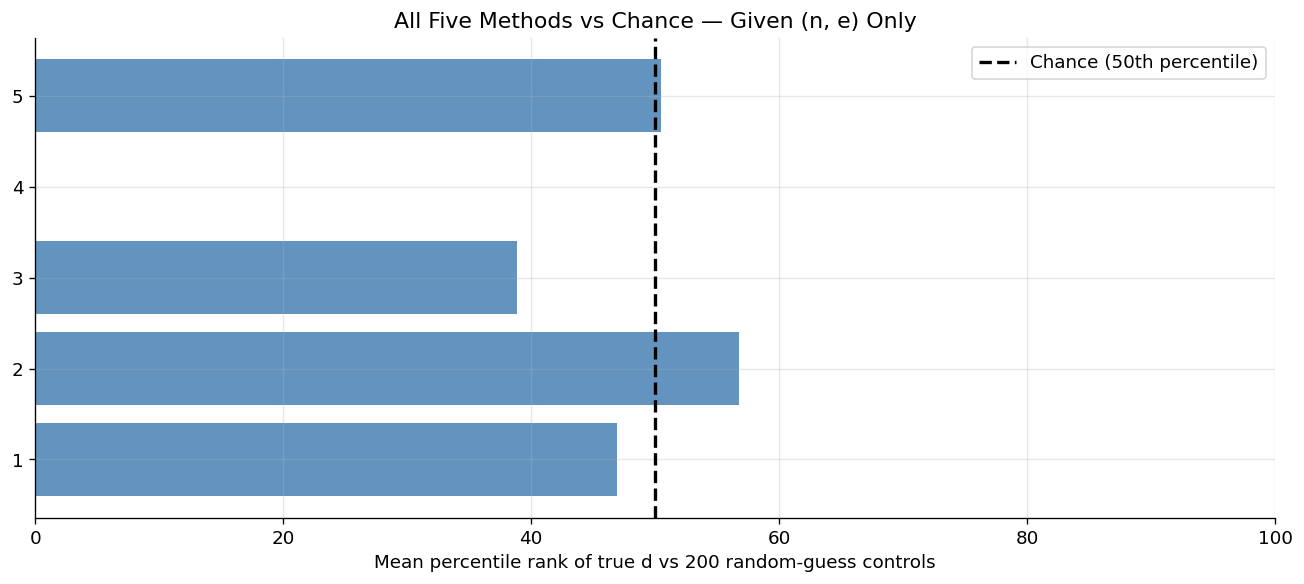


Strongest signal: 4 — Content+Public+Private=Hash (requires Hash to be exposed)

None of methods 1-5 takes only (n, e) and outputs d exactly. What each produces is a percentile rank: how unusual the true d looks under that method's geometry compared to 200-random-but-valid wrong guesses per key. 50 == indistinguishable from chance, matching the prior finding that the RSA cross-check control stayed at chance across all 5 Translator test rounds. The one genuinely ESTABLISHED result of this session is the mod4_theorem: d = e (mod 4) always, proven by elementary number theory, unrelated to sedenions or zero-divisors, and cryptographically insignificant (1 bit of search-space reduction). Methods 1, 2, 3, 5(public-key-only) are AT CHANCE. Method 4 and Method 5 (Hash-exposed scenario) are exact ONLY when a value requiring d to compute (Hash) is separately exposed -- neither is a public-key-only attack.


In [4]:

fig, ax = plt.subplots(figsize=(11, 5))
rows = result['comparison_table']
names = [r['method'].split(' — ')[0] for r in rows]
vals = [r['mean_percentile_vs_chance_50'] for r in rows]
colors = ['crimson' if abs(v-50) > 15 else 'steelblue' for v in vals]
ax.barh(names, vals, color=colors, alpha=0.85)
ax.axvline(50, color='k', ls='--', lw=2, label='Chance (50th percentile)')
ax.set_xlabel('Mean percentile rank of true d vs 200 random-guess controls')
ax.set_title('All Five Methods vs Chance — Given (n, e) Only')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print()
print('Strongest signal:', result['strongest_signal'])
print()
print(result['honest_summary'])


## Ainulindale Reading

**Confidence:** `{}'.format(result.get('confidence',''))`

Run `result.keys()` to explore the full engine output.

In [5]:
print('Engine keys:', list(result.keys()))

Engine keys: ['claim', 'baseline_reference', 'mod4_theorem', 'comparison_table', 'strongest_signal', 'confidence', 'honest_summary']
